In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from src import soporte_correlacion as sp_corr

In [2]:
pd.set_option("display.max_columns",None) #display todas las columnas
df_hr = pd.read_csv("hr_final.csv",index_col=0)

df_hr.head()

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income
0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,single,8,yes,11,3,1,0,8,0,1,6,4,0,5.0,41,4,5993.0
1,no,travel_frequently,research & development,8,1,life sciences,2,3,male,2,2,research scientist,married,1,no,23,4,4,1,10,3,3,10,7,1,7.0,49,2,5130.0
2,yes,travel_rarely,research & development,2,2,other,4,4,male,2,1,laboratory technician,single,6,yes,15,3,2,0,7,3,3,0,0,0,0.0,37,3,2090.0
3,no,travel_frequently,research & development,3,4,life sciences,5,4,female,3,1,research scientist,married,1,yes,11,3,3,0,8,3,3,8,7,3,0.0,33,3,2909.0
4,no,travel_rarely,research & development,2,1,medical,7,1,male,3,1,laboratory technician,married,9,no,12,3,4,1,6,3,3,2,2,2,2.0,27,2,3468.0


In [3]:
df_hr.columns

Index(['attrition', 'business_travel', 'department', 'distance_from_home',
       'education', 'education_field', 'employee_number',
       'environment_satisfaction', 'gender', 'job_involvement', 'job_level',
       'job_role', 'marital_status', 'num_companies_worked', 'over_time',
       'percent_salary_hike', 'performance_rating',
       'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager', 'age',
       'job_satisfaction', 'monthly_income'],
      dtype='str')

### **<font color="red">¿Existe una brecha salarial entre los empleados que se quedan y los que se van?</font>**
      - Herramienta: sns.boxplot(x='attrition', y='monthly_income', data=df)

In [4]:
df_hr["monthly_income"].describe(include=np.number).T.reset_index()

,index,monthly_income
0,count,1474.000000
1,mean,6500.079376
2,std,4702.432869
3,min,1009.000000
4,25%,2909.500000
5,50%,4936.000000
6,75%,8379.000000
7,max,19999.000000


In [5]:
df_hr['salary_cat'] = pd.cut(df_hr['monthly_income'], bins=[0,5000,10000,20000], labels=['bajo','medio','alto'])

In [6]:
crosstab_salary= pd.crosstab(df_hr['salary_cat'], df_hr['attrition'], normalize= 'columns')
print(crosstab_salary)

attrition         no       yes
salary_cat                    
bajo        0.473301  0.689076
medio       0.319579  0.210084
alto        0.207120  0.100840


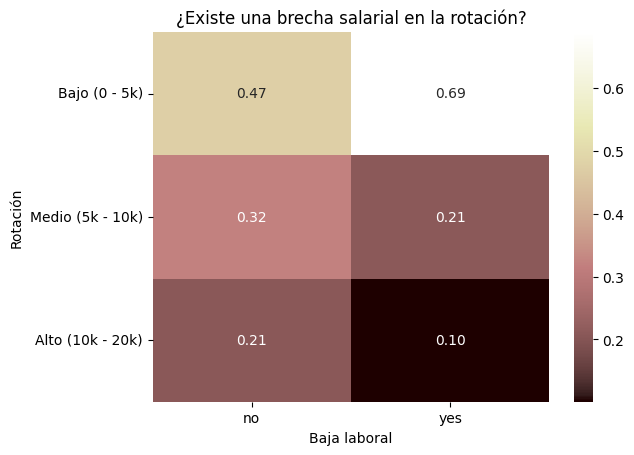

In [7]:
ax = sns.heatmap(crosstab_salary, annot=True, cmap='pink', fmt='.2f')
ax.set_yticklabels(["Bajo (0 - 5k)","Medio (5k - 10k)","Alto (10k - 20k)"], rotation=0)
plt.title('¿Existe una brecha salarial en la rotación?', fontsize=12)
plt.xlabel('Baja laboral')
plt.ylabel('Rotación')

plt.show()


la mayoria de los que se van son los que tienen el salario más bajo.

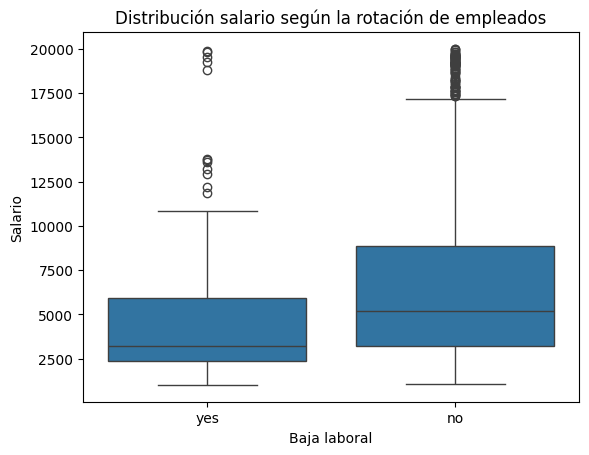

In [8]:
sns.boxplot(data=df_hr,x="attrition", y="monthly_income")
plt.title('Distribución salario según la rotación de empleados', fontsize=12)
plt.xlabel('Baja laboral')
plt.ylabel('Salario')

plt.show()


Existe una brecha salarial entre los empleados que se quedan y los que se van : < monthly_income = > attrition vs  >monthly_income = < attrition. 
Notamos que la mediana del salario de los que se van, es igual al 25% del salario mínimo de los que se quedan.

### **<font color="red">¿El trabajo extra (Overtime) es un detonante para la rotación? </font>**
       - Herramienta: sns.countplot(x='over_time', hue='attrition', data=df)

In [9]:
crosstab = pd.crosstab(df_hr['over_time'], df_hr['attrition'], normalize= 'columns')
print(crosstab)

attrition        no      yes
over_time                   
no         0.773463  0.47479
yes        0.226537  0.52521


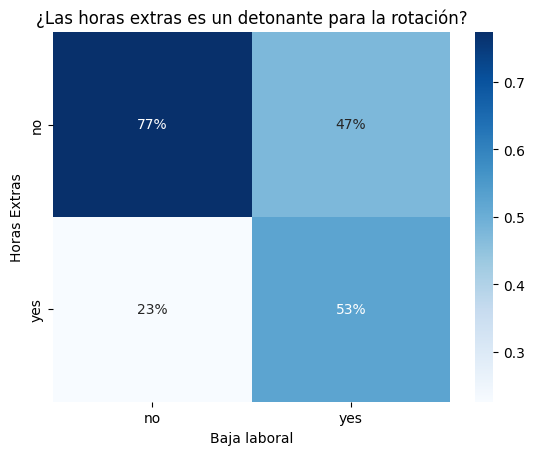

In [10]:
sns.heatmap(crosstab, annot=True, cmap='Blues', fmt='.0%')
plt.title('¿Las horas extras es un detonante para la rotación?', fontsize=12)
plt.xlabel('Baja laboral')
plt.ylabel('Horas Extras')

plt.show()


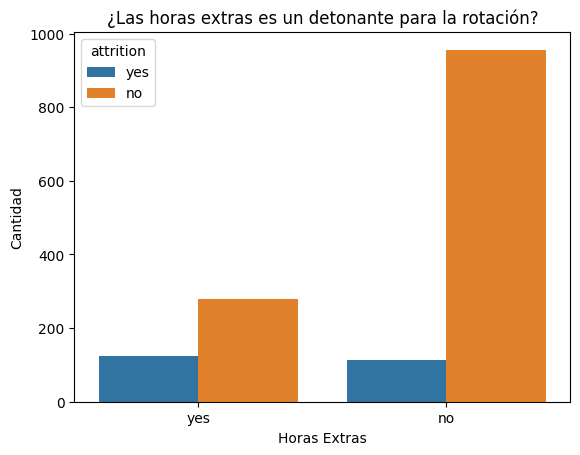

In [11]:
sns.countplot(x='over_time', hue='attrition',data=df_hr)
plt.title('¿Las horas extras es un detonante para la rotación?', fontsize=12)
plt.xlabel('Horas Extras')
plt.ylabel('Cantidad')

plt.show()


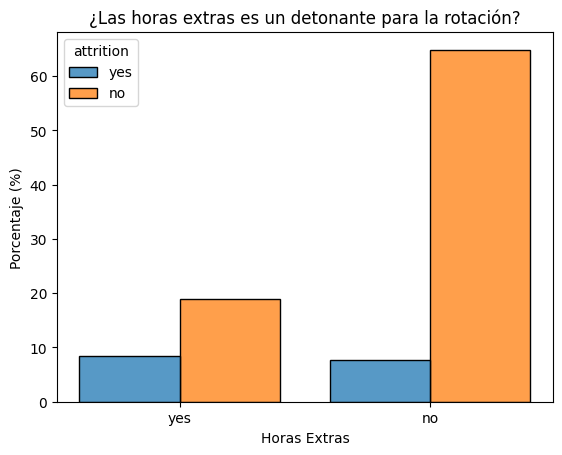

In [12]:
sns.histplot(x='over_time', hue='attrition', data=df_hr, 
             multiple='dodge', shrink=0.8, stat='percent')

plt.title('¿Las horas extras es un detonante para la rotación?', fontsize=12)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Horas Extras')
plt.show()

### **<font color="red">¿Influye la distancia al hogar en la decisión de abandonar la empresa? </font>**
       - Herramienta: sns.kdeplot comparando distance_from_home para ambos grupos de attrition.

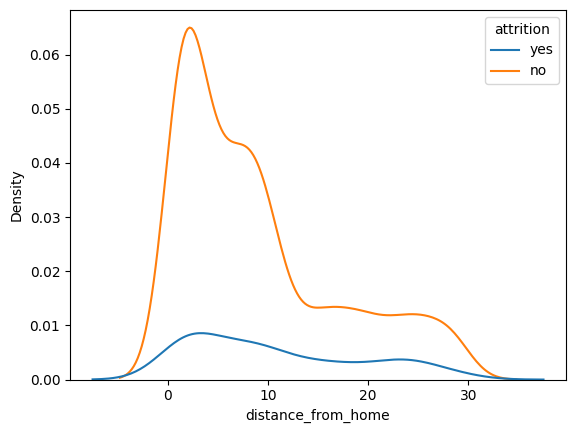

In [13]:
sns.kdeplot(data=df_hr, x="distance_from_home", hue="attrition");
#dibuja la estimación de densidad kernel de `distance_from_home` para cada valor de `attrition`, comparando la distribución de distancias entre los que se quedan y los que se van.

In [14]:
df_hr['distance_cat']= pd.cut(df_hr['distance_from_home'], bins=[0,10,20,30], labels=['Cerca','Medio','Lejos'])

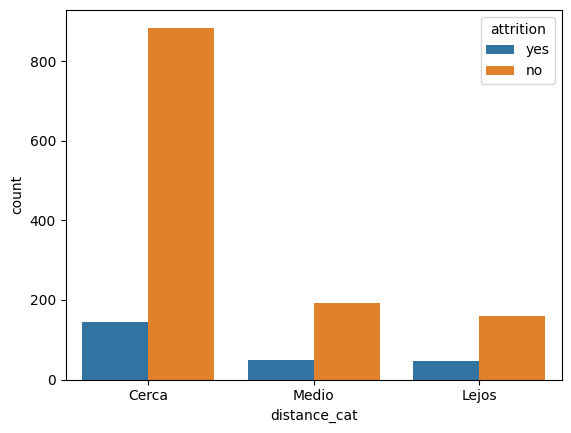

In [15]:
sns.countplot(x='distance_cat', hue='attrition',data=df_hr);

In [16]:
crosstabDisCount = pd.crosstab(df_hr['distance_cat'], df_hr['attrition'], normalize= 'columns')

In [17]:
crosstabDisCount

attrition,no,yes
distance_cat,,
Cerca,0.715210,0.605042
Medio,0.156149,0.201681
Lejos,0.128641,0.193277


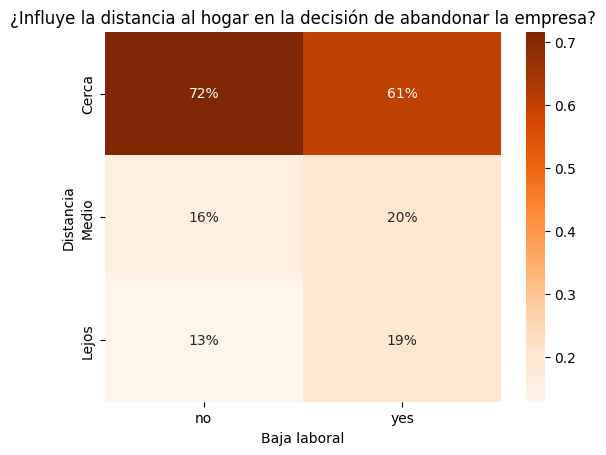

In [18]:
sns.heatmap(crosstabDisCount, annot=True, fmt='.0%',cmap='Oranges')
plt.title('¿Influye la distancia al hogar en la decisión de abandonar la empresa?', fontsize=12)
plt.xlabel('Baja laboral')
plt.ylabel('Distancia')

plt.show()



el 40% de los que se van, viven entre medio y lejos de la empresa

### **<font color="red"> ¿Qué departamentos o roles tienen la tasa de rotación más alta?</font>**
    - Herramienta: Gráfico de barras apiladas o sns.countplot con job_role o department.

<Axes: xlabel='attrition', ylabel='count'>

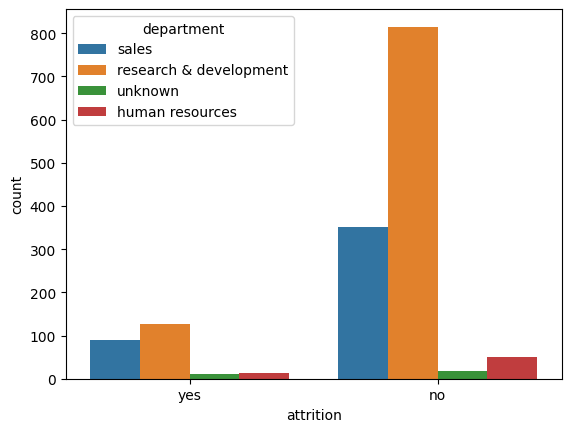

In [19]:
sns.countplot(data=df_hr, x="attrition", hue="department")

No hay patrón claro del porcentaje de rotación por departamento, pero podemos indicar que el 53% de los que se van pertenecen a development, un 37% en ventas. Ventas (Sales) es el punto crítico: En el grupo de los que se quedan (no), representan el 28%. En el grupo de los que se van (yes), suben al 37%. Conclusión: El departamento de Ventas tiene una rotación proporcionalmente más alta que su peso en la empresa.

In [20]:
df_hr['job_level_cat']= pd.cut(df_hr['job_level'], bins=[1,2,3,4,5], labels=['junior','semi-senior','senior','expert'])

In [37]:
pd.crosstab(df_hr['job_level_cat'], df_hr['department'], normalize= 'columns').round(2)

department,human resources,research & development,sales,unknown
job_level_cat,,,,
junior,0.43,0.53,0.65,0.50
semi-senior,0.20,0.25,0.22,0.22
senior,0.13,0.12,0.09,0.28
expert,0.23,0.09,0.04,0.00


In [38]:
pd.crosstab(df_hr['job_level_cat'], df_hr['department'], normalize= 'index').round(2)

department,human resources,research & development,sales,unknown
job_level_cat,,,,
junior,0.02,0.52,0.44,0.02
semi-senior,0.03,0.58,0.37,0.02
senior,0.04,0.60,0.31,0.05
expert,0.10,0.71,0.19,0.00


In [22]:
df_hr.groupby('attrition')['department'].value_counts(normalize=True).round(2)   

attrition  department            
no         research & development    0.66
           sales                     0.28
           human resources           0.04
           unknown                   0.02
yes        research & development    0.53
           sales                     0.37
           human resources           0.05
           unknown                   0.04
Name: proportion, dtype: float64

<Axes: xlabel='attrition', ylabel='count'>

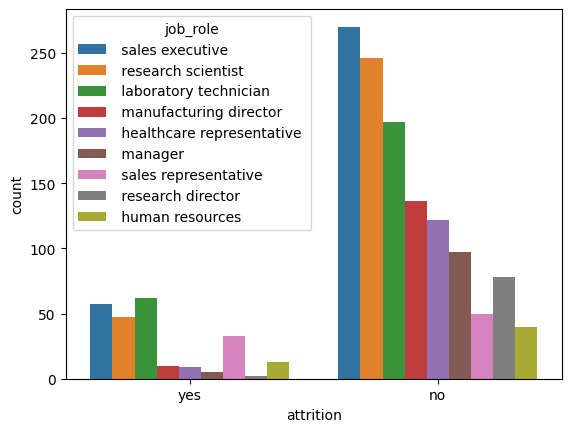

In [41]:
sns.countplot(data=df_hr, x="attrition", hue="job_role",)

In [24]:
pd.crosstab(df_hr['job_role'], df_hr['attrition'], normalize= 'columns').round(2)

attrition,no,yes
job_role,,
healthcare representative,0.10,0.04
human resources,0.03,0.05
laboratory technician,0.16,0.26
manager,0.08,0.02
manufacturing director,0.11,0.04
research director,0.06,0.01
research scientist,0.20,0.20
sales executive,0.22,0.24
sales representative,0.04,0.14


In [25]:
pd.crosstab(df_hr['job_role'], df_hr['attrition'], normalize= 'index').round(2)

attrition,no,yes
job_role,,
healthcare representative,0.93,0.07
human resources,0.75,0.25
laboratory technician,0.76,0.24
manager,0.95,0.05
manufacturing director,0.93,0.07
research director,0.98,0.02
research scientist,0.84,0.16
sales executive,0.83,0.17
sales representative,0.60,0.40


In [26]:
# 26% labotatory technician, 20% research scientist, 24% sales executive

In [27]:
df_hr.groupby('attrition')['job_role'].value_counts(normalize=True).round(2)   

attrition  job_role                  
no         sales executive               0.22
           research scientist            0.20
           laboratory technician         0.16
           manufacturing director        0.11
           healthcare representative     0.10
           manager                       0.08
           research director             0.06
           sales representative          0.04
           human resources               0.03
yes        laboratory technician         0.26
           sales executive               0.24
           research scientist            0.20
           sales representative          0.14
           human resources               0.05
           manufacturing director        0.04
           healthcare representative     0.04
           manager                       0.02
           research director             0.01
Name: proportion, dtype: float64

In [28]:
df_hr.groupby('attrition')['department'].value_counts(normalize=True).round(2)   

attrition  department            
no         research & development    0.66
           sales                     0.28
           human resources           0.04
           unknown                   0.02
yes        research & development    0.53
           sales                     0.37
           human resources           0.05
           unknown                   0.04
Name: proportion, dtype: float64

# 2. Análisis de Satisfacción y Clima
  Se centra en las métricas de bienestar (job_satisfaction, environment_satisfaction, work_life_balance).

### **<font color="red"> ¿Cómo se distribuye la satisfacción laboral según el nivel del puesto (job_level)?</font>**
       * Herramienta: sns.violinplot(x='job_level', y='job_satisfaction', data=df)

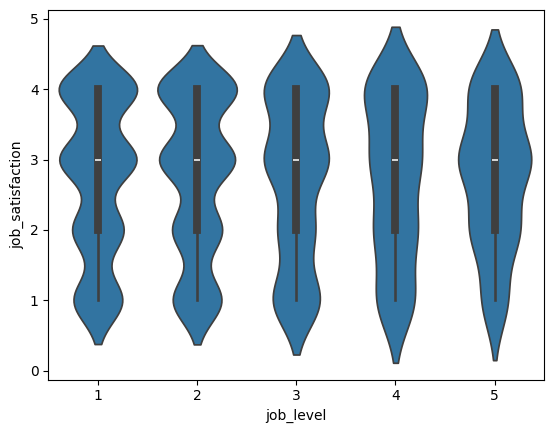

In [29]:
sns.violinplot(data=df_hr,x="job_level",y="job_satisfaction");

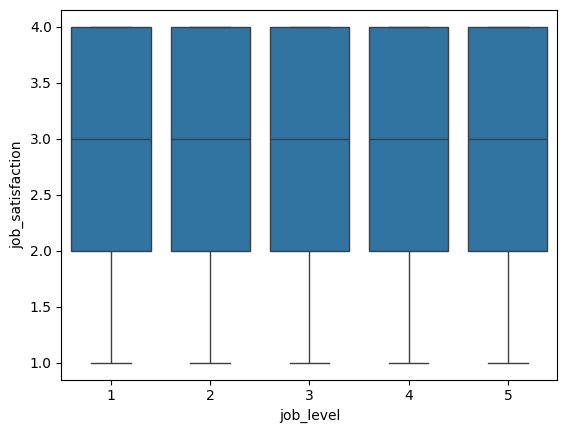

In [30]:
sns.boxplot(data=df_hr,x="job_level",y="job_satisfaction");

**Yo aqui haría un groupby por job level de la media de satisfaction, para aclarar los datos**

In [31]:
df_hr.groupby("job_level")["job_satisfaction"].mean()

job_level
1    2.724265
2    2.733209
3    2.689498
4    2.716981
5    2.753623
Name: job_satisfaction, dtype: float64

### **<font color="red"> ¿Existe relación entre el equilibrio vida-trabajo y la satisfacción en el entorno?</font>**
    - Herramienta: Matriz de contingencia (Heatmap) entre work_life_balance y environment_satisfaction.

In [32]:
tablaconting1 = pd.crosstab(df_hr["work_life_balance"], df_hr["environment_satisfaction"], normalize="index")*100;  #todas las filas suma el 100%, por ej. un 25% no está contento, por otro lado un 31% 4/4
tablaconting1.style.background_gradient(cmap='Blues')


AttributeError: The '.style' accessor requires jinja2

In [ ]:
tablaconting2 = pd.crosstab(df_hr["work_life_balance"], df_hr["environment_satisfaction"], normalize="columns")*100;  #todas las columnas suma el 100%, por ejemplo, el 58· odia su entorno con equilibrio al 3.
tablaconting2.style.background_gradient(cmap='Blues')

environment_satisfaction,1,2,3,4
work_life_balance,,,,
1,7.042254,4.513889,4.856512,5.567929
2,23.591549,27.083333,22.075055,22.048998
3,58.802817,59.722222,61.368653,62.360802
4,10.563380,8.680556,11.699779,10.022272


<Axes: xlabel='environment_satisfaction', ylabel='work_life_balance'>

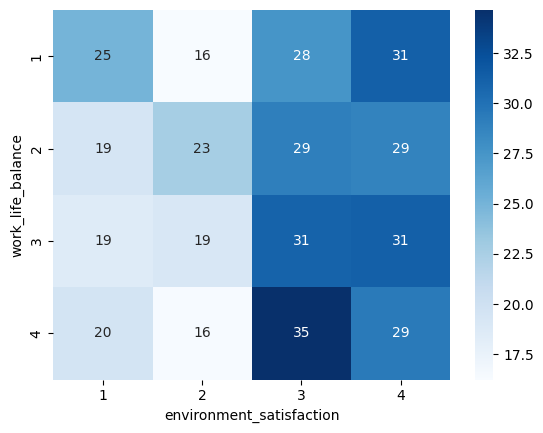

In [ ]:
sns.heatmap(tablaconting1, annot=True, cmap="Blues", cbar=True)


<Axes: xlabel='environment_satisfaction', ylabel='work_life_balance'>

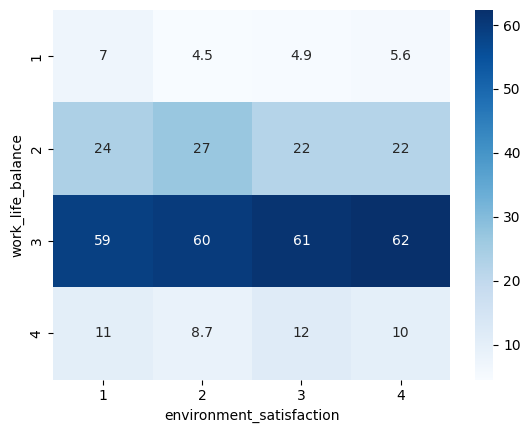

In [ ]:
sns.heatmap(tablaconting2, annot=True, cmap="Blues", cbar=True)

### **<font color="red"> ¿Los empleados con más años bajo el mismo manager tienen mayor satisfacción?</float>**
    - Herramienta: sns.lineplot o sns.barplot comparando years_with_curr_manager con job_satisfaction.

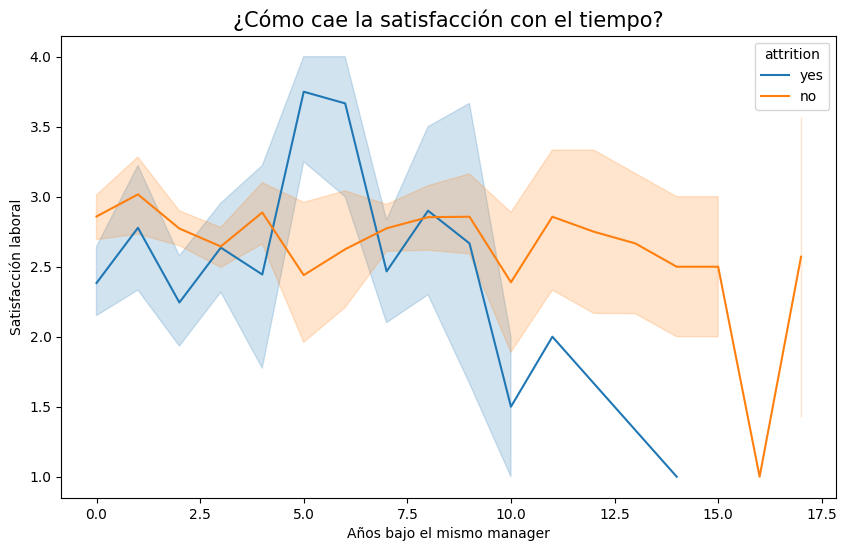

In [62]:
plt.figure(figsize= (10,6))
sns.lineplot(data=df_hr,x="years_with_curr_manager",y="job_satisfaction", hue="attrition")
plt.title('¿Cómo cae la satisfacción con el tiempo?', fontsize=15)
plt.xlabel("Años bajo el mismo manager")
plt.ylabel("Satisfacción laboral")

plt.show()

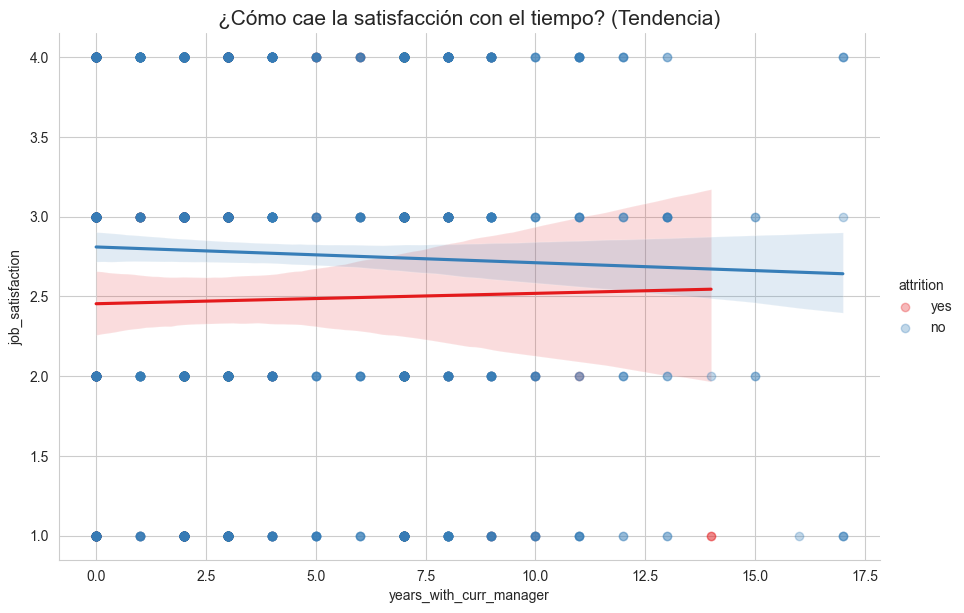

In [ ]:
# Usamos lmplot para crear líneas de tendencia automáticas
sns.lmplot(data=df_hr, 
           x="years_with_curr_manager", 
           y="job_satisfaction", 
           hue="attrition", 
           palette="Set1",
           scatter_kws={'alpha':0.3}, # Hacemos los puntos un poco transparentes
           height=6, aspect=1.5)

# Añadimos títulos que ayuden al insight
plt.title('¿Cómo cae la satisfacción con el tiempo? (Tendencia)', fontsize=15)
plt.show()

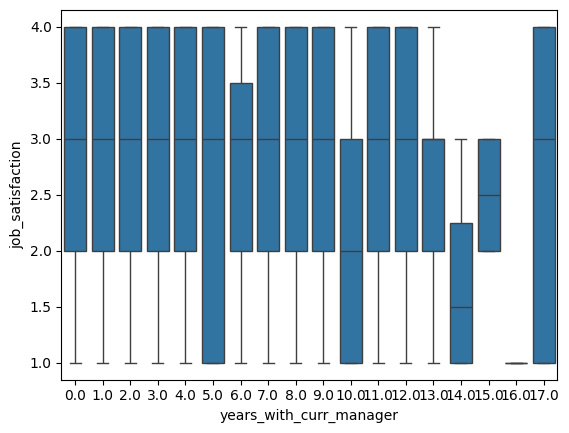

In [ ]:
sns.boxplot(data=df_hr,x="years_with_curr_manager",y="job_satisfaction");

In [ ]:
df_hr["years_bin"] = pd.cut(
    df_hr["years_with_curr_manager"],
    bins=[0,3,6,10,20],
    labels=["0-3","4-6","7-10","10+"]
)

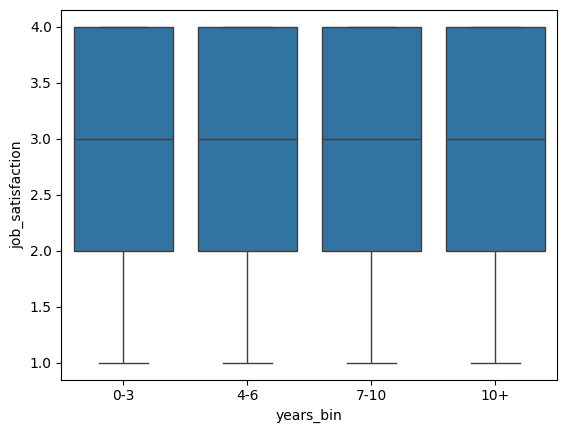

In [ ]:
sns.boxplot(data=df_hr, x="years_bin", y="job_satisfaction");

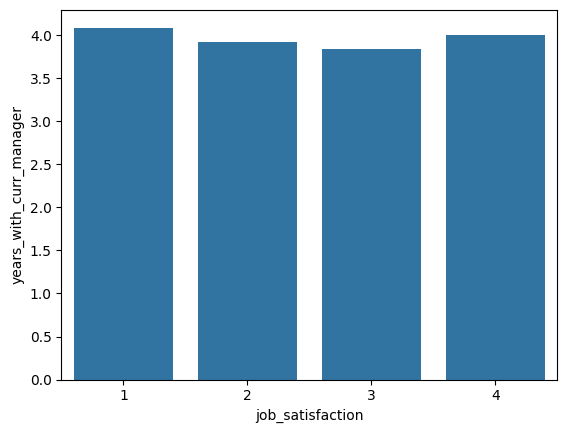

In [ ]:
sns.barplot(data=df_hr,y="years_with_curr_manager",x="job_satisfaction", errorbar=None);

# 3. Correlaciones y Factores Numéricos
  Para identificar qué variables se mueven juntas.

### **<font color="red"> ¿Cuáles son las variables numéricas que más influyen en el ingreso mensual?</font>**
       - Herramienta: Mapa de calor de correlaciones (sns.heatmap(df.corr())) filtrando por monthly_income.

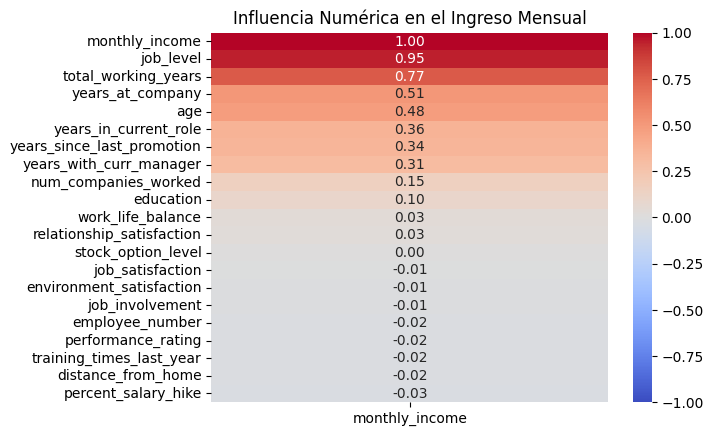

In [ ]:
# Calculamos la matriz de correlación completa (solo numéricas)
corr_matrix = df_hr.corr(numeric_only=True)

# Usamos sort_values para poner las correlaciones más altas arriba
income_corr = corr_matrix[['monthly_income']].sort_values(by='monthly_income', ascending=False)

# 3. Graficamos el Heatmap enfocado
sns.heatmap( income_corr,annot=True,cmap='coolwarm',vmin=-1, vmax=1,fmt=".2f")
# Escala de color: azul (negativo), blanco (cero), rojo (positivo)
# Fija la escala de color de -1 a 1
# Formato de dos decimales

plt.title("Influencia Numérica en el Ingreso Mensual", fontsize=12)
plt.show()

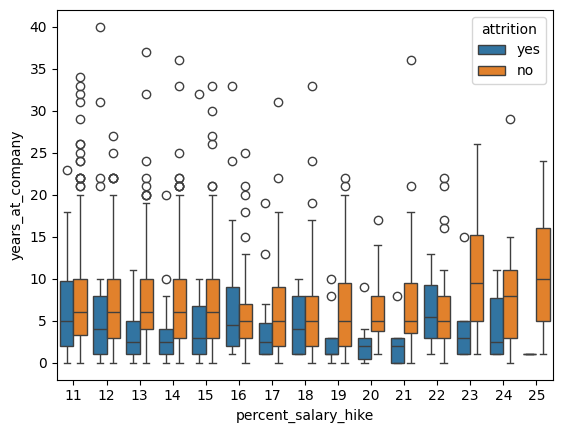

In [ ]:
sns.boxplot(data=df_hr, y="years_at_company", x="percent_salary_hike", hue="attrition");

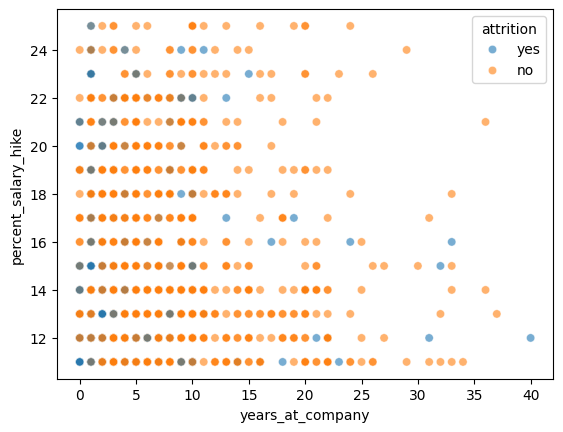

In [ ]:
sns.scatterplot(data=df_hr, x="years_at_company", y="percent_salary_hike", hue="attrition", alpha=0.6);

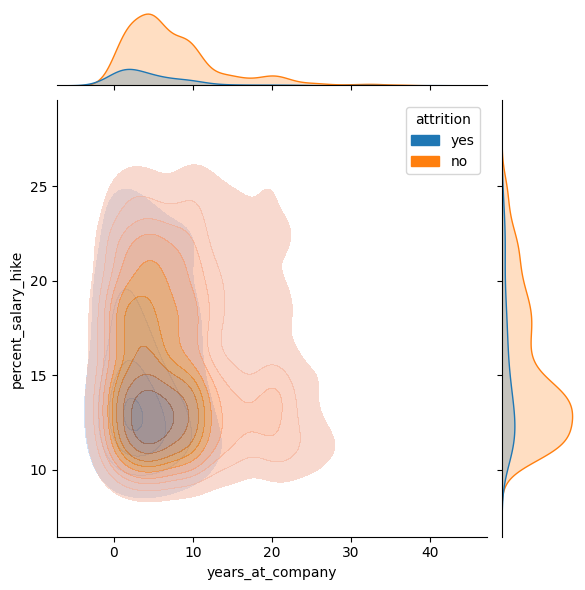

In [ ]:
sns.jointplot(data=df_hr, x="years_at_company", y="percent_salary_hike", hue="attrition", kind="kde", fill=True, alpha=0.5)

### **<font color="red"> ¿Existe una correlación entre el porcentaje de aumento salarial (percent_salary_hike) y el desempeño (performance_rating)?</font>**
       * Herramienta: sns.scatterplot con regresión.

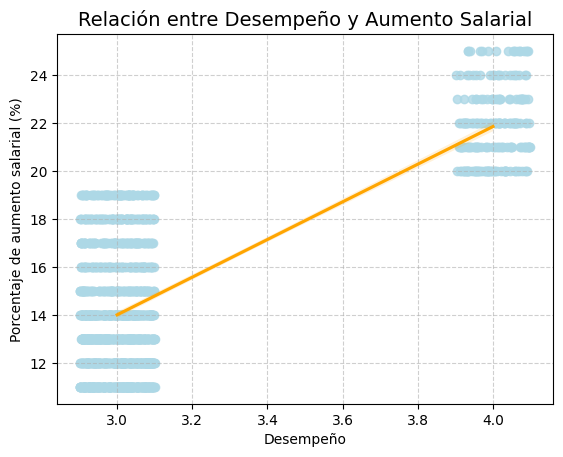

In [56]:

# regplot añade la línea de tendencia y el "sombreado" (intervalo de confianza)
sns.regplot(data=df_hr,x="performance_rating",y="percent_salary_hike", x_jitter=0.1, color="lightblue", line_kws={'color': 'orange'}) # x_jitter Separa un poco los puntos para ver densidad

plt.title("Relación entre Desempeño y Aumento Salarial", fontsize=14)
plt.xlabel("Desempeño")
plt.ylabel("Porcentaje de aumento salarial (%)")
plt.grid(True, linestyle='--', alpha=0.6) # Añade una rejilla para leer mejor
plt.show()

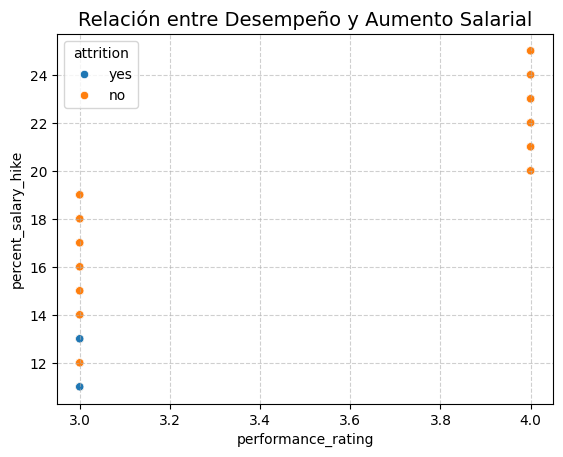

In [ ]:
# regplot añade la línea de tendencia y el "sombreado" (intervalo de confianza)
sns.scatterplot(data=df_hr,x="performance_rating",y="percent_salary_hike", hue= "attrition")

plt.title("Relación entre Desempeño y Aumento Salarial", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6) # Añade una rejilla para leer mejor
plt.show()

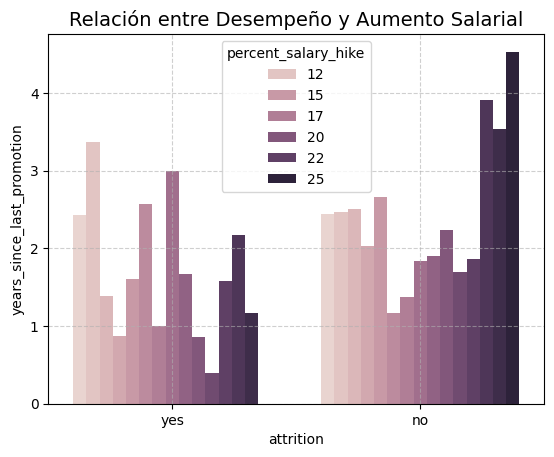

In [ ]:
# regplot añade la línea de tendencia y el "sombreado" (intervalo de confianza)
sns.barplot(data=df_hr,x="attrition",y="years_since_last_promotion", hue= "percent_salary_hike", errorbar=None)

plt.title("Relación entre Desempeño y Aumento Salarial", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6) # Añade una rejilla para leer mejor
plt.show()

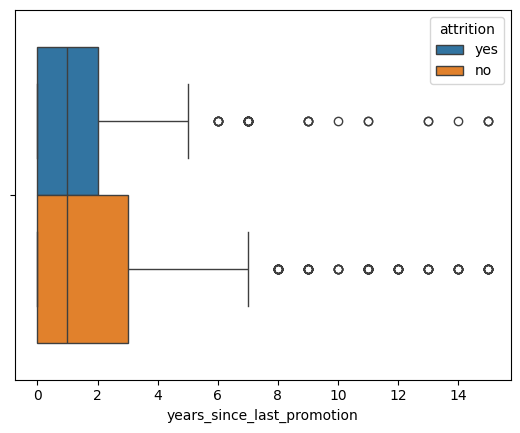

In [ ]:
sns.boxplot(data=df_hr, x="years_since_last_promotion", hue= "attrition");

In [ ]:
df_hr.sample()

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income,salary_cat,distance_cat,job_level_cat,years_bin
883,no,travel_rarely,research & development,9,3,medical,1238,1,male,3,1,research scientist,married,0,no,13,3,2,1,15,5,3,14,10,4,10.0,33,4,2781.0,bajo,Cerca,NaN,7-10


### **<font color="red"> ¿Cómo afecta la edad y los años de experiencia al nivel de ingresos?</font>**
    - Herramienta: sns.jointplot para ver la distribución y la relación entre age y total_working_years.

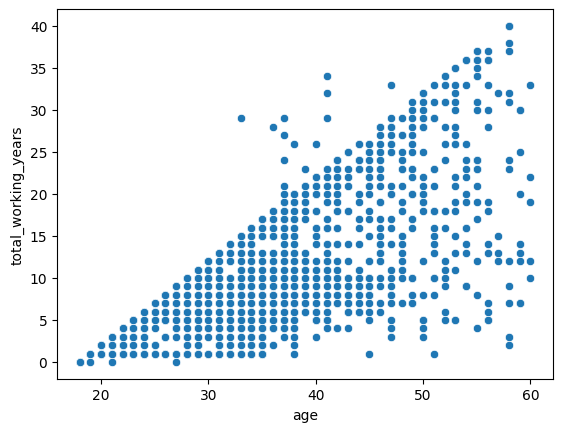

In [ ]:
sns.scatterplot(data=df_hr, x="age",y="total_working_years");

In [ ]:
df_hr = df_hr[df_hr['age'] > df_hr['total_working_years']]

In [ ]:
df_hr = df_hr[(df_hr['age'] - df_hr['total_working_years']) >= 16]

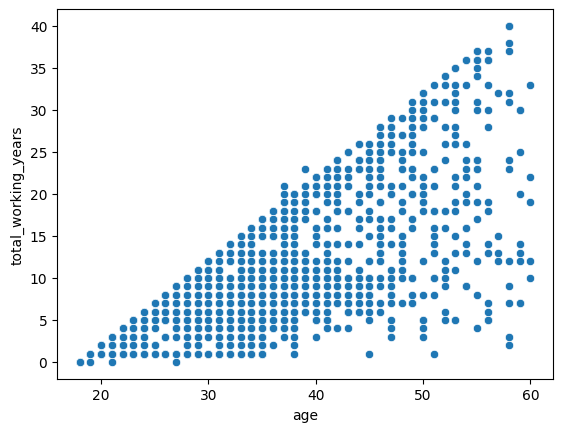

In [ ]:
sns.scatterplot(data=df_hr, x="age",y="total_working_years");

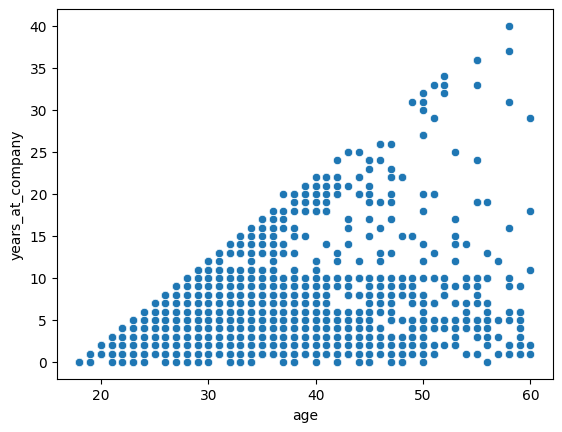

In [ ]:
sns.scatterplot(data=df_hr, x="age",y="years_at_company");

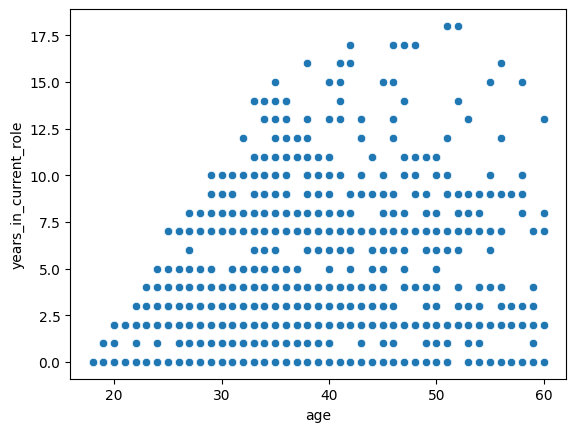

In [ ]:
sns.scatterplot(data=df_hr, x="age",y="years_in_current_role");

In [ ]:
df_hr[(df_hr['total_working_years']>= 25)&(df_hr['age']<=35)] #¡OJO con los datos erróneos!

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income,salary_cat,distance_cat,job_level_cat,years_bin


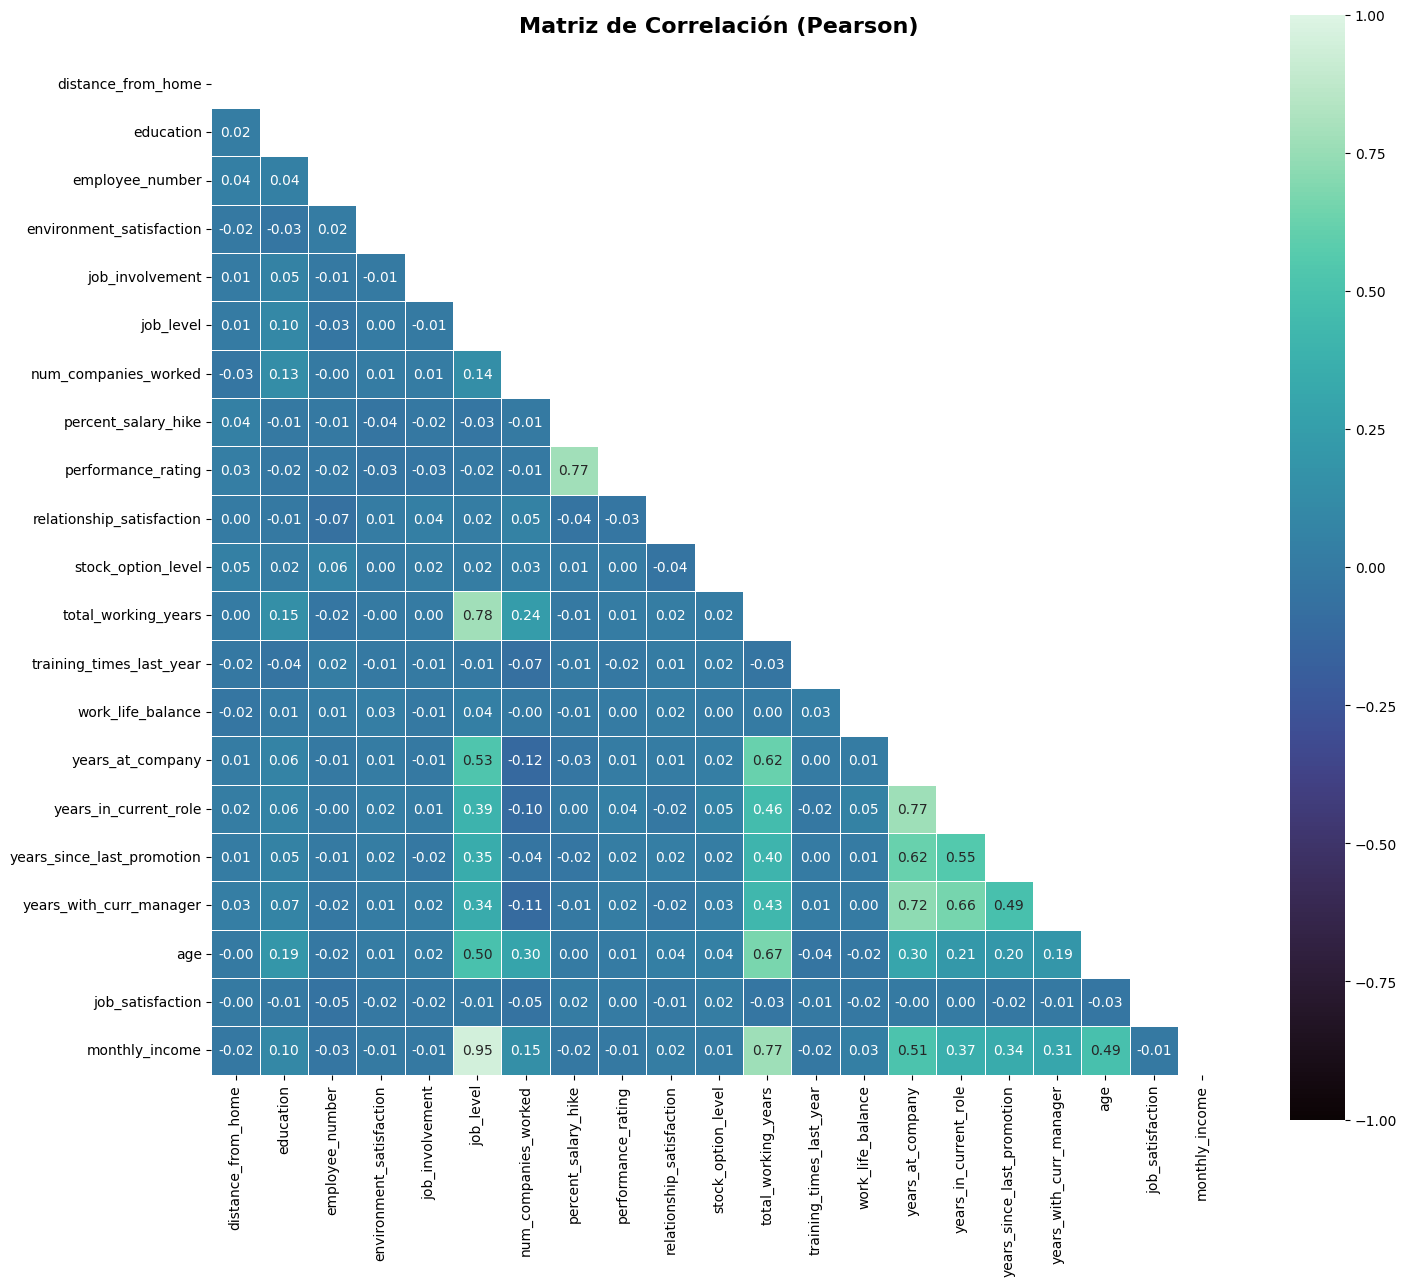

,distance_from_home,education,employee_number,environment_satisfaction,job_involvement,job_level,num_companies_worked,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income
distance_from_home,1.000000,0.017952,0.035255,-0.015000,0.007275,0.006650,-0.031085,0.041187,0.026836,0.003783,0.046640,0.002717,-0.022230,-0.024250,0.012052,0.016391,0.009034,0.025193,-0.001664,-0.004558,-0.016838
education,0.017952,1.000000,0.039864,-0.029191,0.049638,0.100509,0.130896,-0.009656,-0.022720,-0.010961,0.019328,0.145421,-0.041511,0.006827,0.059620,0.060730,0.048123,0.067135,0.192172,-0.011816,0.095597
employee_number,0.035255,0.039864,1.000000,0.015265,-0.009939,-0.027961,-0.001958,-0.011781,-0.018809,-0.067267,0.060248,-0.023686,0.020760,0.012300,-0.013064,-0.003488,-0.006602,-0.018533,-0.016419,-0.049090,-0.025277
environment_satisfaction,-0.015000,-0.029191,0.015265,1.000000,-0.007659,0.002974,0.013301,-0.036785,-0.031283,0.008725,0.001702,-0.001798,-0.009799,0.028295,0.012281,0.024493,0.020187,0.009579,0.009307,-0.020563,-0.007736
job_involvement,0.007275,0.049638,-0.009939,-0.007659,1.000000,-0.007197,0.010588,-0.015932,-0.029955,0.036707,0.021293,0.001988,-0.006280,-0.011159,-0.010505,0.010247,-0.017340,0.021992,0.021088,-0.018199,-0.009020
job_level,0.006650,0.100509,-0.027961,0.002974,-0.007197,1.000000,0.139315,-0.029770,-0.015264,0.017514,0.018527,0.778335,-0.011918,0.038671,0.530384,0.392052,0.350506,0.338738,0.499972,-0.005369,0.949349
num_companies_worked,-0.031085,0.130896,-0.001958,0.013301,0.010588,0.139315,1.000000,-0.006644,-0.012021,0.050438,0.031422,0.238563,-0.072079,-0.004567,-0.123732,-0.095385,-0.038157,-0.108998,0.296066,-0.050468,0.147201
percent_salary_hike,0.041187,-0.009656,-0.011781,-0.036785,-0.015932,-0.029770,-0.006644,1.000000,0.774217,-0.040994,0.005593,-0.014042,-0.005607,-0.006298,-0.030959,0.003308,-0.023682,-0.009131,0.004584,0.015215,-0.022990
performance_rating,0.026836,-0.022720,-0.018809,-0.031283,-0.029955,-0.015264,-0.012021,0.774217,1.000000,-0.030899,0.002292,0.014540,-0.023146,0.001617,0.011479,0.038057,0.021698,0.017598,0.007452,0.003752,-0.011123
relationship_satisfaction,0.003783,-0.010961,-0.067267,0.008725,0.036707,0.017514,0.050438,-0.040994,-0.030899,1.000000,-0.044591,0.016944,0.008696,0.019421,0.012483,-0.019313,0.024470,-0.017492,0.035374,-0.012227,0.022018


In [ ]:
sp_corr.matriz_correlacion_visual(df_hr)

In [ ]:
df_yes = df_hr[df_hr["attrition"] == "yes"]

In [ ]:
df_no = df_hr[df_hr["attrition"] == "no"] 

In [ ]:
df_yes.sample(5)

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income,salary_cat,distance_cat,job_level_cat,years_bin
669,yes,travel_rarely,research & development,6,3,medical,932,4,male,3,1,laboratory technician,married,7,yes,21,4,4,0,8,2,1,2,2,2,2.0,39,1,2404.0,bajo,Cerca,NaN,0-3
126,yes,travel_rarely,research & development,23,4,medical,165,4,female,3,3,healthcare representative,married,1,no,12,3,4,1,40,3,2,40,10,15,6.0,58,4,8900.0,medio,Lejos,semi-senior,4-6
439,yes,travel_frequently,research & development,20,3,life sciences,587,1,male,3,3,healthcare representative,married,3,no,12,3,1,0,12,2,3,1,0,0,0.0,31,3,9824.0,medio,Medio,semi-senior,NaN
1032,yes,non-travel,research & development,2,3,life sciences,1458,1,female,2,1,laboratory technician,single,2,yes,23,4,2,0,11,2,4,1,0,0,0.0,39,1,3646.0,bajo,Cerca,NaN,NaN
122,yes,non-travel,research & development,14,4,life sciences,161,2,female,3,1,research scientist,married,9,yes,18,3,1,3,7,2,3,5,4,4,3.0,56,2,4963.0,bajo,Medio,NaN,0-3


In [ ]:
df_no.sample(5)

,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,job_involvement,job_level,job_role,marital_status,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age,job_satisfaction,monthly_income,salary_cat,distance_cat,job_level_cat,years_bin
623,no,travel_frequently,research & development,5,4,life sciences,861,2,male,2,1,research scientist,divorced,9,no,12,3,2,1,10,3,2,5,4,0,3.0,30,4,3761.0,bajo,Cerca,NaN,0-3
409,no,travel_frequently,research & development,29,2,life sciences,547,1,female,3,2,research scientist,divorced,2,no,11,3,2,1,19,3,3,5,4,0,2.0,42,3,4556.0,bajo,Lejos,junior,0-3
738,no,travel_rarely,research & development,1,1,life sciences,1026,4,female,2,4,manufacturing director,unknown,1,no,16,3,3,1,21,3,3,21,6,11,8.0,39,4,12742.0,alto,Cerca,senior,7-10
606,no,travel_frequently,research & development,16,4,life sciences,838,3,female,2,1,research scientist,single,1,no,16,3,3,0,6,3,3,5,2,1,3.0,34,4,2553.0,bajo,Medio,NaN,0-3
1421,no,non-travel,research & development,1,1,medical,2000,3,female,3,3,research director,married,0,no,18,3,1,2,14,3,1,13,8,5,12.0,47,2,11957.0,alto,Cerca,semi-senior,10+


In [ ]:
df_yes.describe(include=np.number).T.round(2)

,count,mean,std,min,25%,50%,75%,max
distance_from_home,237.0,10.72,8.47,1.0,3.0,9.0,17.0,29.0
education,237.0,2.82,1.01,1.0,2.0,3.0,4.0,5.0
employee_number,237.0,1010.95,581.41,1.0,514.0,1017.0,1486.0,2055.0
environment_satisfaction,237.0,2.47,1.17,1.0,1.0,3.0,4.0,4.0
job_involvement,237.0,2.51,0.78,1.0,2.0,3.0,3.0,4.0
job_level,237.0,1.63,0.94,1.0,1.0,1.0,2.0,5.0
num_companies_worked,237.0,2.95,2.67,0.0,1.0,1.0,5.0,9.0
percent_salary_hike,237.0,15.08,3.78,11.0,12.0,14.0,17.0,25.0
performance_rating,237.0,3.16,0.36,3.0,3.0,3.0,3.0,4.0
relationship_satisfaction,237.0,2.60,1.13,1.0,2.0,3.0,4.0,4.0


In [ ]:
df_no.describe(include=np.number).T.round(2)

,count,mean,std,min,25%,50%,75%,max
distance_from_home,1226.0,8.91,8.00,1.0,2.00,7.0,13.00,29.0
education,1226.0,2.92,1.03,1.0,2.00,3.0,4.00,5.0
employee_number,1226.0,1024.86,606.33,2.0,481.25,1016.5,1567.00,2068.0
environment_satisfaction,1226.0,2.78,1.07,1.0,2.00,3.0,4.00,4.0
job_involvement,1226.0,2.77,0.69,1.0,2.00,3.0,3.00,4.0
job_level,1226.0,2.13,1.10,1.0,1.00,2.0,3.00,5.0
num_companies_worked,1226.0,2.63,2.46,0.0,1.00,2.0,4.00,9.0
percent_salary_hike,1226.0,15.24,3.64,11.0,12.00,14.0,18.00,25.0
performance_rating,1226.0,3.15,0.36,3.0,3.00,3.0,3.00,4.0
relationship_satisfaction,1226.0,2.73,1.07,1.0,2.00,3.0,4.00,4.0


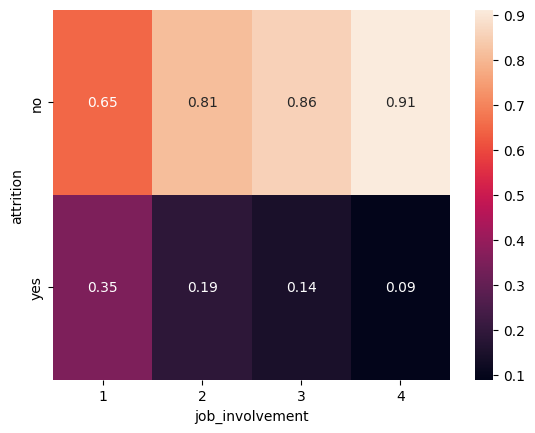

In [ ]:
tabla = pd.crosstab(df_hr["attrition"], df_hr["job_involvement"], normalize="columns")
sns.heatmap(tabla, annot=True);